In [ ]:
'''
Fire Season Timing — Turkey Ecoregion Scale
----------------------------------------------------------------------------------------------------
Computes fire season timing metrics (onset, peak, end, season length)
for all WWF RESOLVE ecoregions intersecting Turkey, for years 2003–2024.

Data sources:
- MODIS Terra active fire: MODIS/061/MOD14A1
- MODIS Aqua active fire:  MODIS/061/MYD14A1
- Ecoregions:              RESOLVE/ECOREGIONS/2017
- Country boundary:        USDOS/LSIB_SIMPLE/2017

Output:
- outputs/turkey_ecoregions/<ECO_ID>_<ECO_NAME>.csv  (per ecoregion)
- outputs/turkey_ecoregions/master_turkey.csv        (combined)
'''

import ee
import pandas as pd
import matplotlib.pyplot as plt
import os
import time

In [ ]:
# Authenticate and initialize ----------------------------------------------------------------------
ee.Initialize(project='fire-seasons')

In [ ]:
# PARAMETERS ---------------------------------------------------------------------------------------

FIRE_MASK_MIN   = 8     # FireMask threshold: >= 8 = nominal + high confidence only
ONSET_THRESHOLD = 0.05  # Cumulative fraction threshold for fire season onset (5%)
END_THRESHOLD   = 0.95  # Cumulative fraction threshold for fire season end (95%)
MIN_DETECTIONS  = 20    # Minimum annual fire detections required to compute metrics
YEARS           = list(range(2003, 2026))  # Full study period: 2003–2025

In [6]:
# LOAD MODIS COLLECTIONS ---------------------------------------------------------------------------
# Terra and Aqua are loaded once here at module level.
# Per-year and per-day filtering is handled inside get_daily_counts().

terra = ee.ImageCollection("MODIS/061/MOD14A1").select('FireMask')
aqua  = ee.ImageCollection("MODIS/061/MYD14A1").select('FireMask')

print('Terra image count:', terra.size().getInfo())
print('Aqua image count:', aqua.size().getInfo())
print('Terra and Aqua collections loaded.')

Terra image count: 9439
Aqua image count: 8619
Terra and Aqua collections loaded.


In [ ]:
# LOAD TURKEY ECOREGIONS ---------------------------------------------------------------------------

# Turkey boundary from LSIB
turkey = ee.FeatureCollection("USDOS/LSIB_SIMPLE/2017") \
           .filter(ee.Filter.eq('country_na', 'Turkey'))

# RESOLVE ecoregions clipped to Turkey
ecoregions_turkey = ee.FeatureCollection("RESOLVE/ECOREGIONS/2017").filterBounds(turkey.geometry())

# Inspect
n_eco    = ecoregions_turkey.size().getInfo()
eco_list = ecoregions_turkey.select(['ECO_ID', 'ECO_NAME']).getInfo()

print(f'Number of ecoregions intersecting Turkey: {n_eco}')
print()
for f in eco_list['features']:
    print(f['properties']['ECO_ID'], '|', f['properties']['ECO_NAME'])

Number of ecoregions intersecting Turkey: 14

786 | Anatolian conifer and deciduous mixed forests
804 | Southern Anatolian montane conifer and deciduous forests
646 | Balkan mixed forests
650 | Caucasus mixed forests
665 | Euxine-Colchic broadleaf forests
652 | Central Anatolian steppe and woodlands
662 | Eastern Anatolian deciduous forests
688 | Zagros Mountains forest steppe
703 | Northern Anatolian conifer and deciduous forests
725 | Central Anatolian steppe
727 | Eastern Anatolian montane steppe
739 | Syrian xeric grasslands and shrublands
785 | Aegean and Western Turkey sclerophyllous and mixed forests
791 | Eastern Mediterranean conifer-broadleaf forests


In [11]:
# BUILD ECOREGION RECORD LIST ----------------------------------------------------------------------

# Converts the GEE FeatureCollection into a plain Python list of dicts
# so we can iterate over ecoregions without repeated GEE calls.

eco_records = []
for f in eco_list['features']:
    eco_records.append({
        'eco_id'   : f['properties']['ECO_ID'],
        'eco_name' : f['properties']['ECO_NAME'],
        'geometry' : ee.Geometry(f['geometry'])
    })

print(f'Loaded {len(eco_records)} ecoregion records.')

Loaded 14 ecoregion records.


In [8]:
# FUNCTION: get_daily_counts -----------------------------------------------------------------------


def get_daily_counts(eco_geometry, year):
    """
    Compute daily MODIS active fire detection counts for a given
    ecoregion geometry and calendar year.

    Combines Terra (MOD14A1) and Aqua (MYD14A1) by taking the pixel-wise
    maximum across sensors for each day, deduplicating detections that
    appear in both sensors on the same day.

    All 365 daily counts are retrieved in a SINGLE reduceRegion call
    by stacking all daily images into one multi-band image using toBands().
    This avoids the 'Too many concurrent aggregations' error that occurs
    when reduceRegion is called inside a mapped function.

    Parameters
    ----------
    eco_geometry : ee.Geometry
        The geometry of the ecoregion to compute counts for.
    year : int
        The calendar year to process (e.g. 2008).

    Returns
    -------
    pd.DataFrame
        DataFrame with columns:
          - doy           : int, day of year (1-indexed)
          - n_detections  : int, number of fire pixels detected
        One row per day of the year (365 or 366 rows).
    """

    import calendar

    start  = ee.Date.fromYMD(year, 1, 1)
    end    = ee.Date.fromYMD(year + 1, 1, 1)
    n_days = 366 if calendar.isleap(year) else 365

    # Pre-filter both collections to this year
    terra_year = terra.filterDate(start, end)
    aqua_year  = aqua.filterDate(start, end)

    # Fallback empty image for days where a sensor returns no image
    empty = ee.Image.constant(0).rename('FireMask').toUint8()

    # Server-side list of day offsets: [0, 1, 2, ... n_days-1]
    day_seq = ee.List.sequence(0, n_days - 1)

    def make_daily_image(d):
        """
        For a single day offset d, build a deduplicated binary fire image.
        Returns a single-band image named by its DOY (e.g. 'day_001').
        No reduceRegion here — reduction happens once outside this function.
        """
        d        = ee.Number(d)
        date     = start.advance(d, 'day')
        date_end = date.advance(1, 'day')

        terra_day = terra_year.filterDate(date, date_end)
        aqua_day  = aqua_year.filterDate(date, date_end)

        # Use empty fallback if sensor has no image for this day
        t = ee.Image(ee.Algorithms.If(
            terra_day.size().gt(0),
            terra_day.select('FireMask').max(),
            empty
        ))
        a = ee.Image(ee.Algorithms.If(
            aqua_day.size().gt(0),
            aqua_day.select('FireMask').max(),
            empty
        ))

        # Pixel-wise max across sensors = deduplication
        combined    = t.max(a)
        fire_binary = combined.gte(FIRE_MASK_MIN).unmask(0)

        # Name this band by its DOY so we can identify it after toBands()
        # ee.Number.format creates a string like '001', '002', ... '365'
        band_name = ee.String('day_').cat(
            d.add(1).toInt().format('%03d')
        )

        return fire_binary.rename(band_name)

    # Build a collection of 365 single-band images
    daily_collection = ee.ImageCollection(day_seq.map(make_daily_image))

    # Stack all 365 bands into ONE multi-band image
    # This is the key change — instead of 365 separate images,
    # we now have one image with 365 bands (one per day)
    stacked = daily_collection.toBands()

    # ONE single reduceRegion call on the entire stacked image
    # This counts fire pixels for all 365 days in a single aggregation
    counts_dict = stacked.reduceRegion(
        reducer   = ee.Reducer.sum(),
        geometry  = eco_geometry,
        scale     = 1000,
        maxPixels = 1e9
    ).getInfo()  # one single getInfo() call — brings all 365 counts at once

    # counts_dict looks like: {'0_day_001': 5, '1_day_002': 0, ...}
    # Parse it back into a tidy DataFrame
    rows = []
    for band_name, count in sorted(counts_dict.items()):
        # Extract the DOY number from the band name (e.g. '0_day_001' → 1)
        doy = int(band_name.split('_')[-1])
        rows.append({
            'doy'         : doy,
            'n_detections': int(count) if count is not None else 0
        })

    return pd.DataFrame(rows)

In [9]:
# FUNCTION: compute_timing_metrics -----------------------------------------------------------------

def compute_timing_metrics(df, year):
    """
    Compute fire season timing metrics from a daily detection count DataFrame.

    Onset and end are defined by percentile thresholds on the cumulative
    detection fraction (5% and 95% respectively). Peak is defined as the
    fire activity centroid — the detection-weighted mean DOY — which is
    more robust to sparse outlier detections than the rolling-mean maximum
    and is guaranteed to fall within the onset–end window.

    Returns None if total detections fall below MIN_DETECTIONS, or if
    onset/end cannot be computed.

    Parameters
    ----------
    df : pd.DataFrame
        Daily counts DataFrame with columns 'doy' and 'n_detections',
        as returned by get_daily_counts().
    year : int
        The calendar year being processed (used for logging only).

    Returns
    -------
    dict or None
        Dict with keys: year, onset_doy, peak_doy, end_doy,
        season_length, n_detections.
        Returns None if metrics cannot be computed.
    """

    total = df['n_detections'].sum()

    if total < MIN_DETECTIONS:
        print(f'  {year}: insufficient detections ({total}), skipping.')
        return None

    df = df.copy().sort_values('doy')
    cumulative = df['n_detections'].cumsum()
    cum_frac   = cumulative / total

    # Onset: first DOY where cumulative fraction reaches 5%
    onset_rows = df[cum_frac >= ONSET_THRESHOLD]
    # End: first DOY where cumulative fraction reaches 95%
    end_rows   = df[cum_frac >= END_THRESHOLD]

    if onset_rows.empty or end_rows.empty:
        print(f'  {year}: could not compute onset or end, skipping.')
        return None

    onset_doy = int(onset_rows.iloc[0]['doy'])
    end_doy   = int(end_rows.iloc[0]['doy'])

    # Peak: fire activity centroid (detection-weighted mean DOY)
    # More robust than rolling-mean maximum; always falls within onset–end window
    weights   = df['n_detections']
    peak_doy  = int(round((df['doy'] * weights).sum() / weights.sum()))

    # Validate peak is within onset–end window
    if not (onset_doy <= peak_doy <= end_doy):
        print(f'  {year}: WARNING — peak ({peak_doy}) outside onset–end window '
              f'({onset_doy}–{end_doy}), flagging.')

    # Season length inclusive of both endpoints
    season_length = end_doy - onset_doy + 1

    return {
        'year'         : year,
        'onset_doy'    : onset_doy,
        'peak_doy'     : peak_doy,
        'end_doy'      : end_doy,
        'season_length': season_length,
        'n_detections' : int(total)
    }

In [12]:
# FULL PIPELINE LOOP — ALL ECOREGIONS x ALL YEARS --------------------------------------------------

# Saves a per-ecoregion CSV after each ecoregion completes so progress
# is not lost if the run is interrupted.

output_dir = 'outputs/turkey_ecoregions'
os.makedirs(output_dir, exist_ok=True)

all_metrics = []

for eco in eco_records:
    eco_id   = eco['eco_id']
    eco_name = eco['eco_name']
    geometry = eco['geometry']

    print(f'\n=== {eco_name} (ID: {eco_id}) ===')
    eco_metrics = []

    for year in YEARS:
        t0 = time.time()

        try:
            df_year = get_daily_counts(geometry, year)
            metrics = compute_timing_metrics(df_year, year)

            if metrics is not None:
                metrics['eco_id']   = eco_id
                metrics['eco_name'] = eco_name
                eco_metrics.append(metrics)
                all_metrics.append(metrics)

        except Exception as e:
            print(f'  {year}: ERROR — {e}')
            continue

        t1 = time.time()
        print(f'  {year}: done in {t1 - t0:.1f}s')

    # Save per-ecoregion CSV immediately after finishing all years
    if eco_metrics:
        eco_df    = pd.DataFrame(eco_metrics)
        safe_name = eco_name.replace(' ', '_').replace('/', '_')
        eco_path  = f'{output_dir}/{eco_id}_{safe_name}.csv'
        eco_df.to_csv(eco_path, index=False)
        print(f'  Saved {len(eco_metrics)} years → {os.path.abspath(eco_path)}')
    else:
        print(f'  No valid years for {eco_name}, skipping CSV.')

print('\nAll ecoregions complete.')


=== Anatolian conifer and deciduous mixed forests (ID: 786) ===
  2003: done in 9.1s
  2004: done in 7.9s
  2005: done in 13.5s
  2006: done in 11.1s
  2007: done in 8.8s
  2008: done in 8.3s
  2009: done in 7.1s
  2010: done in 7.0s
  2011: done in 11.4s
  2012: done in 9.2s
  2013: done in 10.0s
  2014: done in 10.8s
  2015: done in 28.6s
  2016: done in 8.4s
  2017: done in 9.8s
  2018: done in 9.5s
  2019: done in 9.6s
  2020: done in 10.7s
  2021: done in 11.6s
  2022: done in 10.1s
  2023: done in 11.0s
  2024: done in 8.1s
  Saved 22 years → c:\Users\ibekar\Documents\GitProjects\TGPF\outputs\turkey_ecoregions\786_Anatolian_conifer_and_deciduous_mixed_forests.csv

=== Southern Anatolian montane conifer and deciduous forests (ID: 804) ===
  2003: done in 18.5s
  2004: done in 21.4s
  2005: done in 9.9s
  2006: done in 11.2s
  2007: done in 10.6s
  2008: done in 10.6s
  2009: done in 9.3s
  2010: done in 10.4s
  2011: done in 19.1s
  2012: done in 13.9s
  2013: done in 9.4s
  2014

In [13]:
# COMBINE ALL RESULTS INTO MASTER CSV --------------------------------------------------------------

master_df = pd.DataFrame(all_metrics)

# Reorder columns
master_df = master_df[['eco_id', 'eco_name', 'year',
                        'onset_doy', 'peak_doy', 'end_doy',
                        'season_length', 'n_detections']]

master_path = f'{output_dir}/master_turkey.csv'
master_df.to_csv(master_path, index=False)

print(f'Master CSV saved: {master_df.shape[0]} ecoregion-year rows.')
print(f'Path: {os.path.abspath(master_path)}')
print()
print(master_df.head(10))

Master CSV saved: 308 ecoregion-year rows.
Path: c:\Users\ibekar\Documents\GitProjects\TGPF\outputs\turkey_ecoregions\master_turkey.csv

   eco_id                                       eco_name  year  onset_doy  \
0     786  Anatolian conifer and deciduous mixed forests  2003         94   
1     786  Anatolian conifer and deciduous mixed forests  2004         81   
2     786  Anatolian conifer and deciduous mixed forests  2005         74   
3     786  Anatolian conifer and deciduous mixed forests  2006         86   
4     786  Anatolian conifer and deciduous mixed forests  2007         82   
5     786  Anatolian conifer and deciduous mixed forests  2008         69   
6     786  Anatolian conifer and deciduous mixed forests  2009        126   
7     786  Anatolian conifer and deciduous mixed forests  2010         81   
8     786  Anatolian conifer and deciduous mixed forests  2011        141   
9     786  Anatolian conifer and deciduous mixed forests  2012         81   

   peak_doy  en

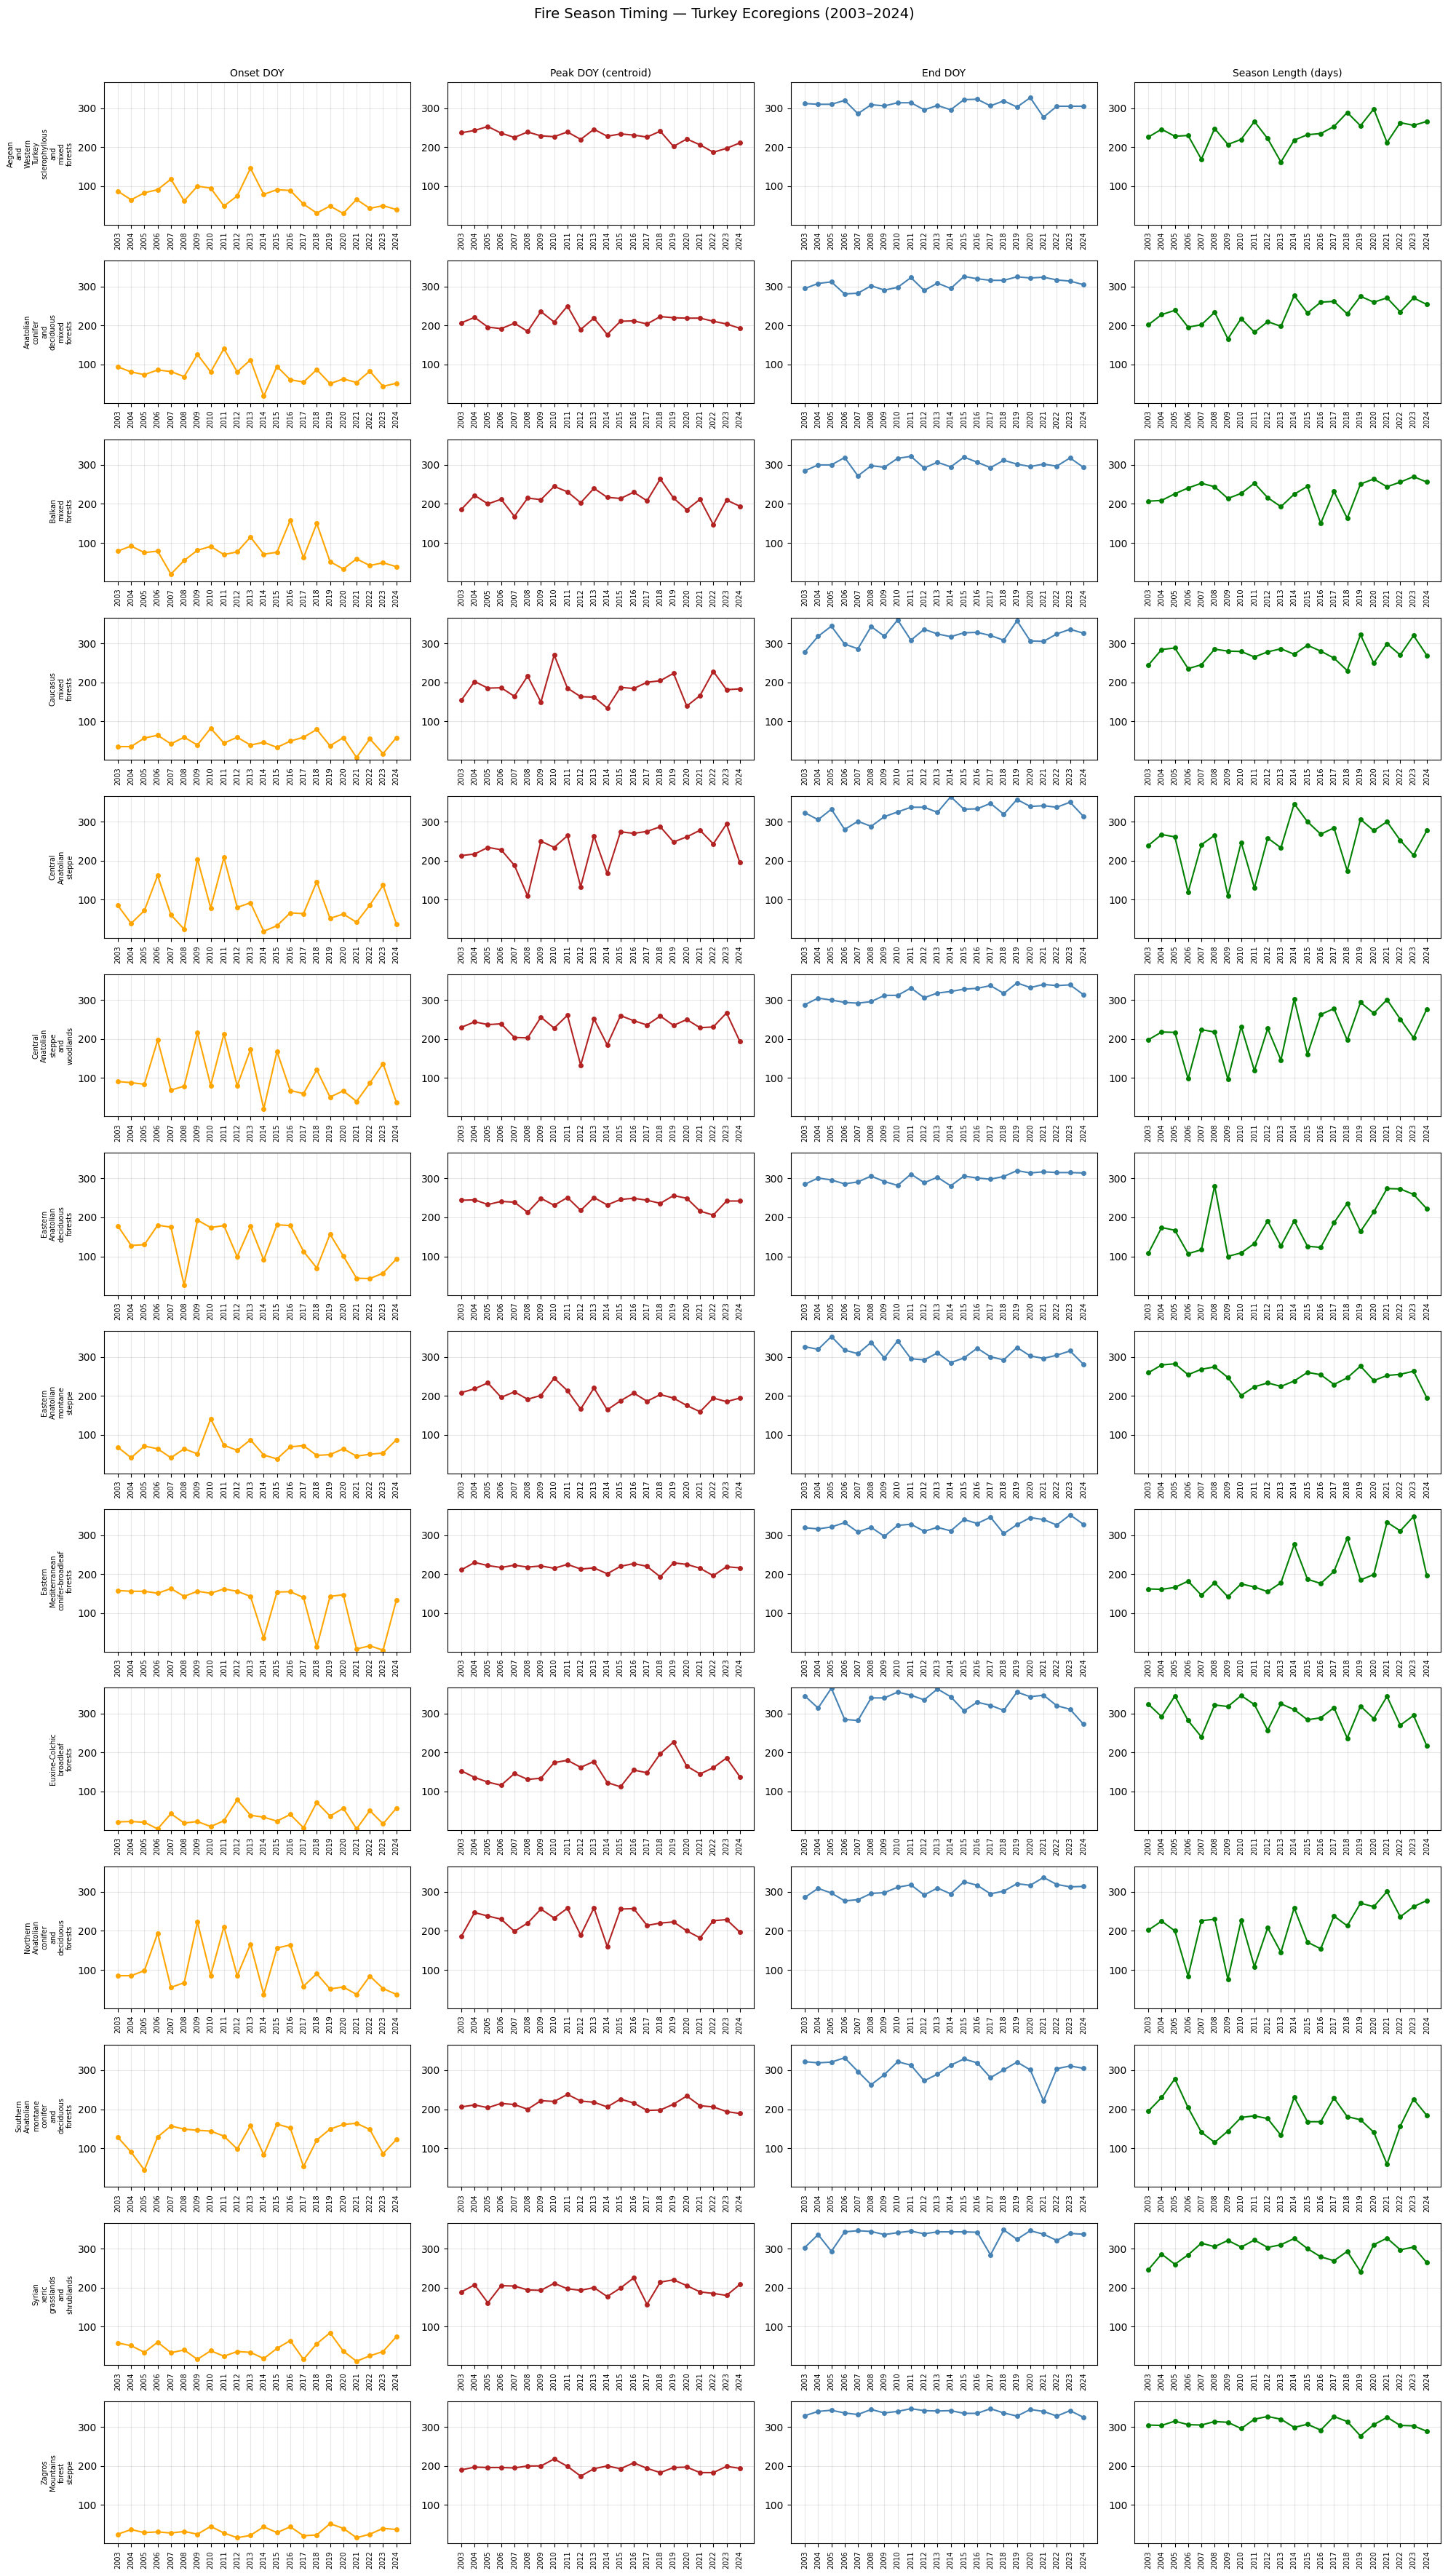

In [31]:
n_ecos    = master_df['eco_name'].nunique()
eco_names = master_df['eco_name'].unique()

fig, axes = plt.subplots(n_ecos, 4, figsize=(20, n_ecos * 2.5))
fig.suptitle('Fire Season Timing — Turkey Ecoregions (2003–2024)',
             fontsize=14, y=1.01)

metrics = [
    ('onset_doy',     'Onset DOY',            'orange'),
    ('peak_doy',      'Peak DOY (centroid)',   'firebrick'),
    ('end_doy',       'End DOY',              'steelblue'),
    ('season_length', 'Season Length (days)', 'green'),
]

for row_idx, eco_name in enumerate(sorted(eco_names)):
    eco_df = master_df[master_df['eco_name'] == eco_name].sort_values('year')

    for col_idx, (metric, title, color) in enumerate(metrics):
        ax = axes[row_idx, col_idx]
        ax.plot(eco_df['year'], eco_df[metric],
                marker='o', color=color, linewidth=1.5, markersize=4)
        ax.set_ylim(1, 366)      # same for all panels
        ax.grid(True, alpha=0.3)
        ax.set_xticks(eco_df['year'])
        ax.tick_params(axis='x', rotation=90, labelsize=7)

        if row_idx == 0:
            ax.set_title(title, fontsize=10)
        if col_idx == 0:
            ax.set_ylabel(eco_name.replace(' ', '\n'), fontsize=7)

plt.tight_layout()
plt.savefig(f'{output_dir}/timing_per_ecoregion_shared.png',
            dpi=150, bbox_inches='tight')
plt.show()

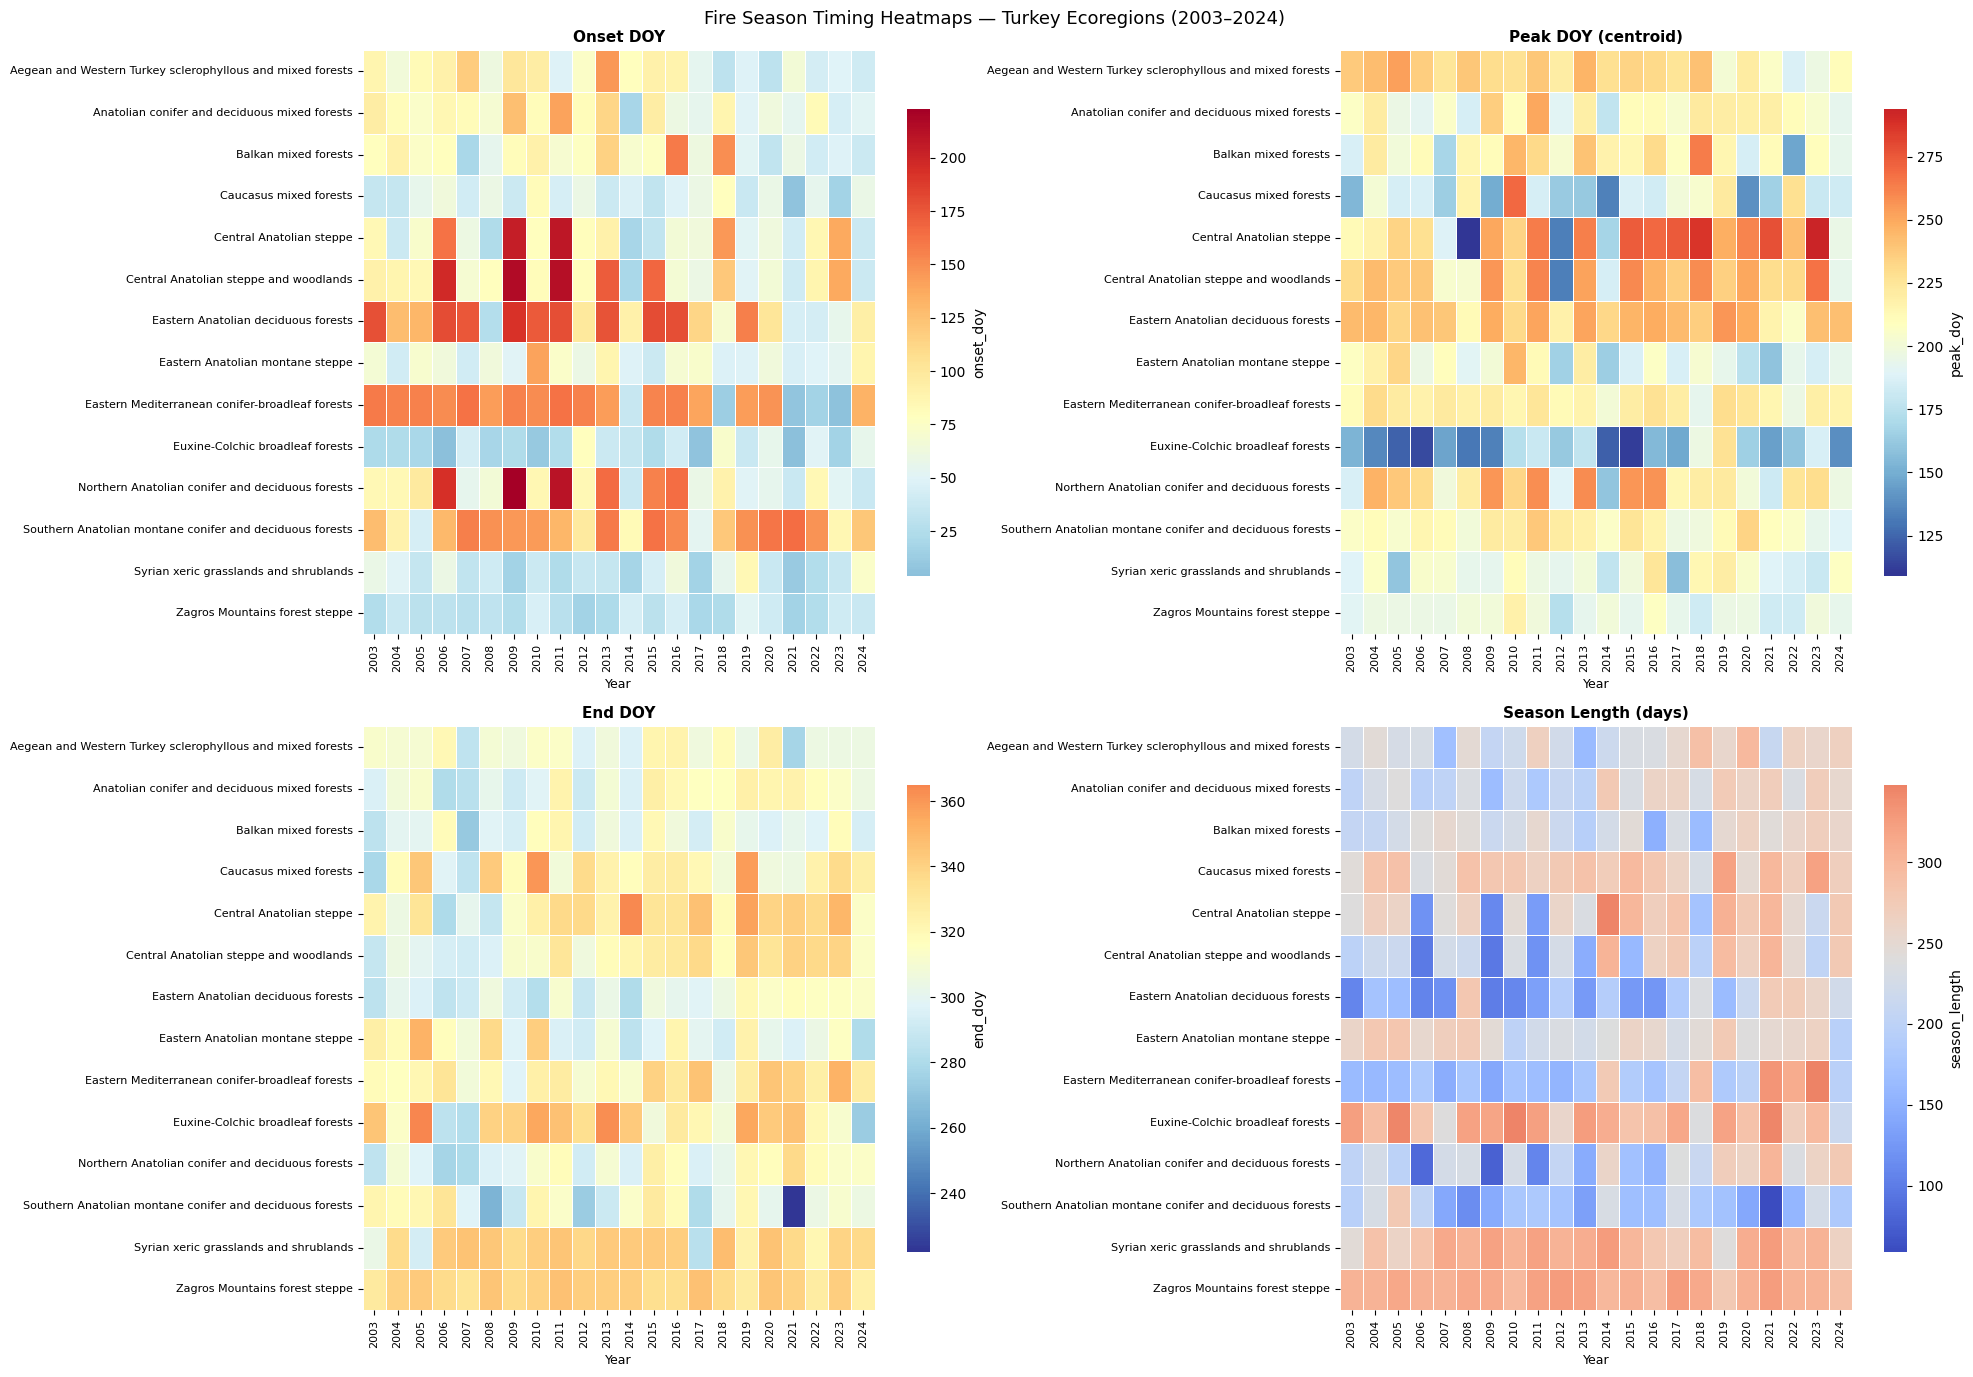

In [29]:
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle('Fire Season Timing Heatmaps — Turkey Ecoregions (2003–2024)', fontsize=13)

metrics = [
    ('onset_doy',     'Onset DOY',            'RdYlBu_r'),  # blue=early, red=late
    ('peak_doy',      'Peak DOY (centroid)',   'RdYlBu_r'),
    ('end_doy',       'End DOY',              'RdYlBu_r'),
    ('season_length', 'Season Length (days)', 'coolwarm'),    # red=short, green=long
]

for ax, (metric, title, cmap) in zip(axes.flatten(), metrics):
    pivot = master_df.pivot(index='eco_name', columns='year', values=metric)

    # Diverging: center the colormap around the median value of each metric
    vmin   = pivot.values.min()
    vmax   = pivot.values.max()
    center = pivot.values.mean()

    sns.heatmap(
        pivot,
        ax         = ax,
        cmap       = cmap,
        center     = center,
        vmin       = vmin,
        vmax       = vmax,
        linewidths = 0.4,
        linecolor  = 'white',
        annot      = False,
        cbar_kws   = {'shrink': 0.8, 'label': metric}
    )

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Year', fontsize=9)
    ax.set_ylabel('')
    ax.tick_params(axis='y', labelsize=8)
    ax.tick_params(axis='x', labelsize=8, rotation=90)

plt.tight_layout()
# plt.savefig(f'{output_dir}/heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

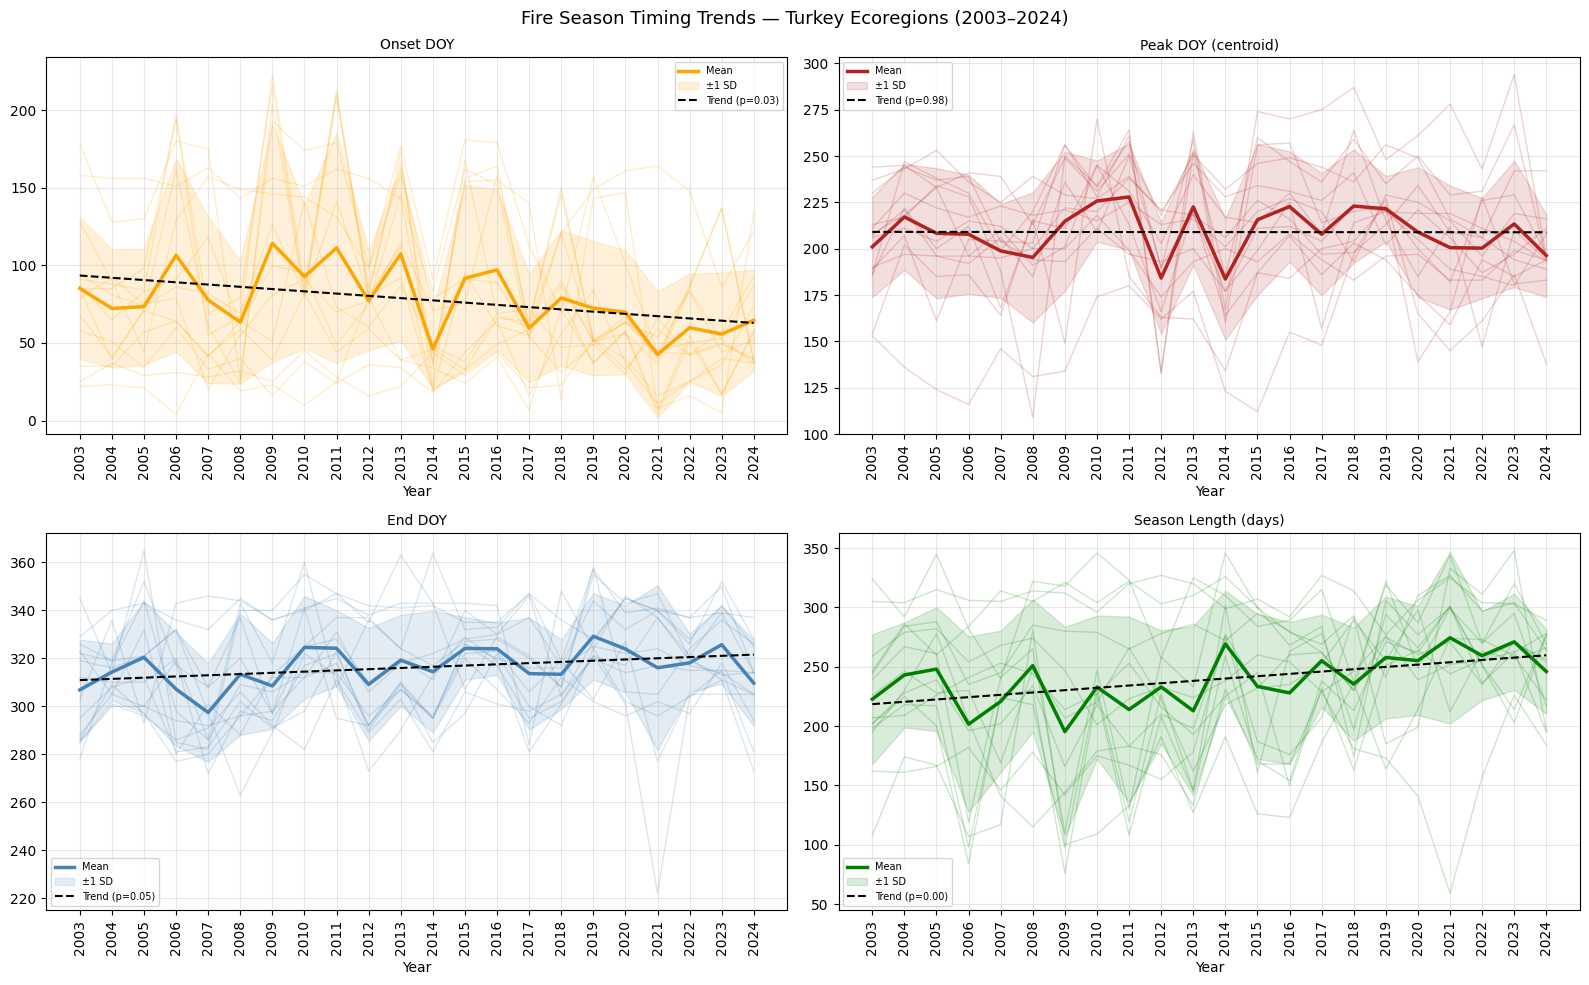

In [17]:
from scipy import stats

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Fire Season Timing Trends — Turkey Ecoregions (2003–2024)', fontsize=13)

metrics = [
    ('onset_doy',     'Onset DOY',            'orange'),
    ('peak_doy',      'Peak DOY (centroid)',   'firebrick'),
    ('end_doy',       'End DOY',              'steelblue'),
    ('season_length', 'Season Length (days)', 'green'),
]

for ax, (metric, title, color) in zip(axes.flatten(), metrics):
    # Plot each ecoregion as a faint line
    for eco_name, group in master_df.groupby('eco_name'):
        ax.plot(group['year'], group[metric],
                color=color, alpha=0.2, linewidth=1)

    # Plot the cross-ecoregion mean per year as a bold line
    yearly_mean = master_df.groupby('year')[metric].mean()
    yearly_std  = master_df.groupby('year')[metric].std()
    years       = yearly_mean.index

    ax.plot(years, yearly_mean, color=color, linewidth=2.5, label='Mean')
    ax.fill_between(years,
                    yearly_mean - yearly_std,
                    yearly_mean + yearly_std,
                    color=color, alpha=0.15, label='±1 SD')

    # Fit and plot overall trend line
    slope, intercept, r, p, _ = stats.linregress(years, yearly_mean)
    trend = [slope * y + intercept for y in years]
    ax.plot(years, trend, color='black', linewidth=1.5,
            linestyle='--', label=f'Trend (p={p:.2f})')

    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Year')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(years)
    ax.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.savefig(f'{output_dir}/trends.png', dpi=150, bbox_inches='tight')
plt.show()

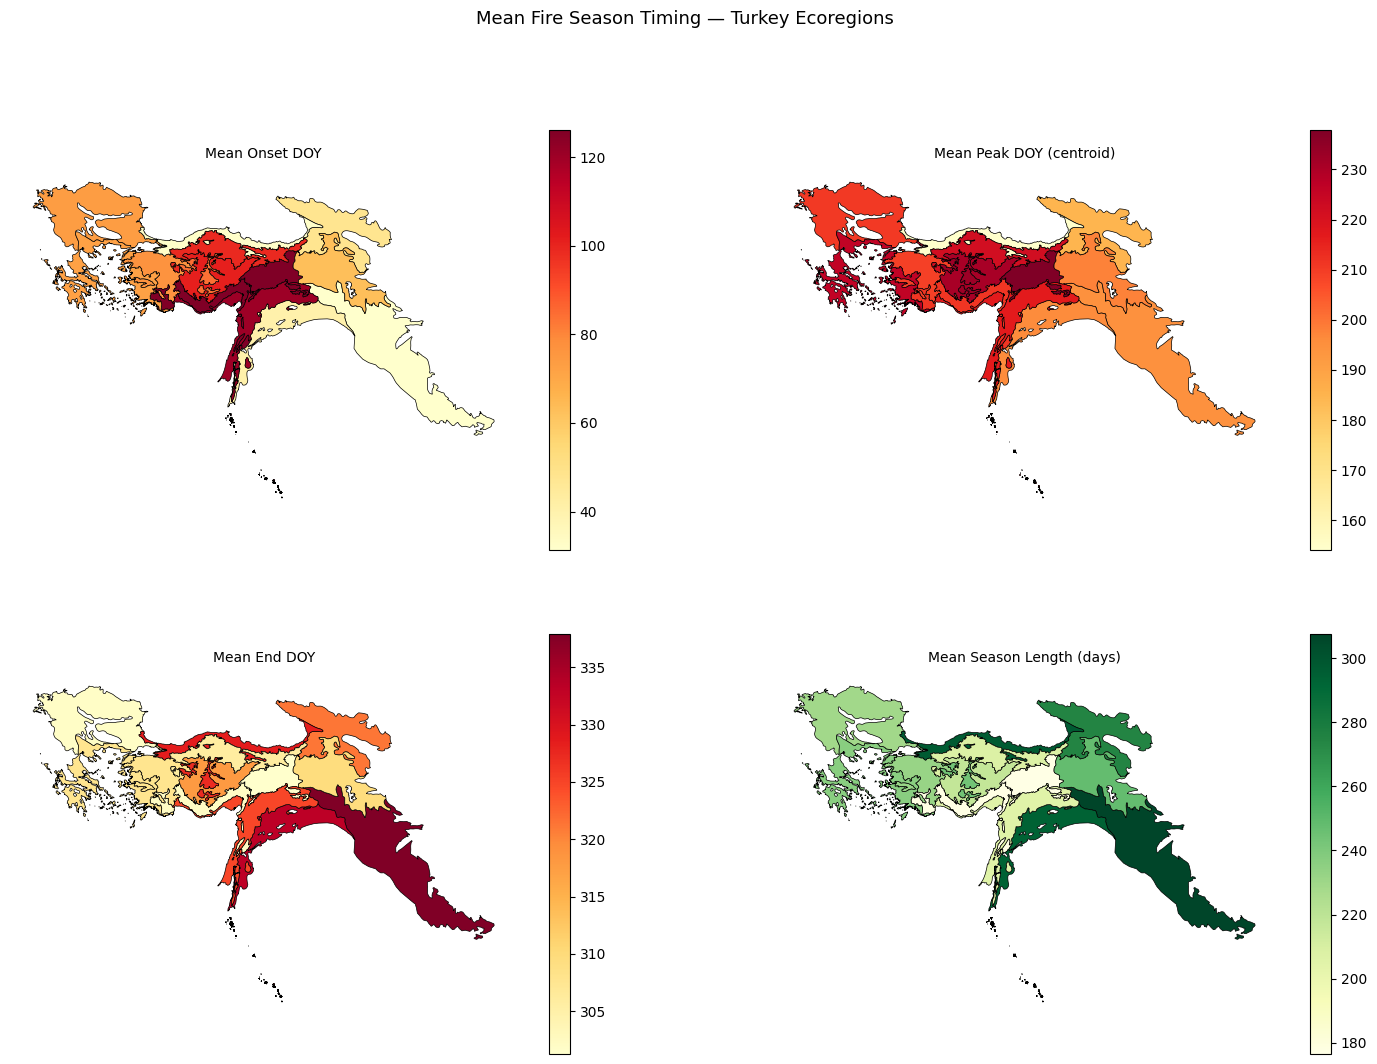

In [23]:
import geopandas as gpd
from shapely.geometry import shape

# Compute mean metrics per ecoregion across all years
mean_metrics = master_df.groupby('eco_name')[
    ['onset_doy', 'peak_doy', 'end_doy', 'season_length']
].mean().reset_index()

# Build GeoDataFrame directly from the GEE features we already loaded
# eco_list was fetched earlier — it has both geometries and properties
rows = []
for f in eco_list['features']:
    eco_name = f['properties']['ECO_NAME']
    if eco_name in mean_metrics['eco_name'].values:
        rows.append({
            'eco_name': eco_name,
            'geometry': shape(f['geometry'])
        })

eco_gdf    = gpd.GeoDataFrame(rows, crs='EPSG:4326')
eco_merged = eco_gdf.merge(mean_metrics, on='eco_name')

# Plot
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Mean Fire Season Timing — Turkey Ecoregions', fontsize=13)

metrics = [
    ('onset_doy',     'Mean Onset DOY',           'YlOrRd'),
    ('peak_doy',      'Mean Peak DOY (centroid)',  'YlOrRd'),
    ('end_doy',       'Mean End DOY',              'YlOrRd'),
    ('season_length', 'Mean Season Length (days)', 'YlGn'),
]

for ax, (metric, title, cmap) in zip(axes.flatten(), metrics):
    eco_merged.plot(column=metric, ax=ax, cmap=cmap,
                    legend=True, edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=10)
    ax.set_axis_off()

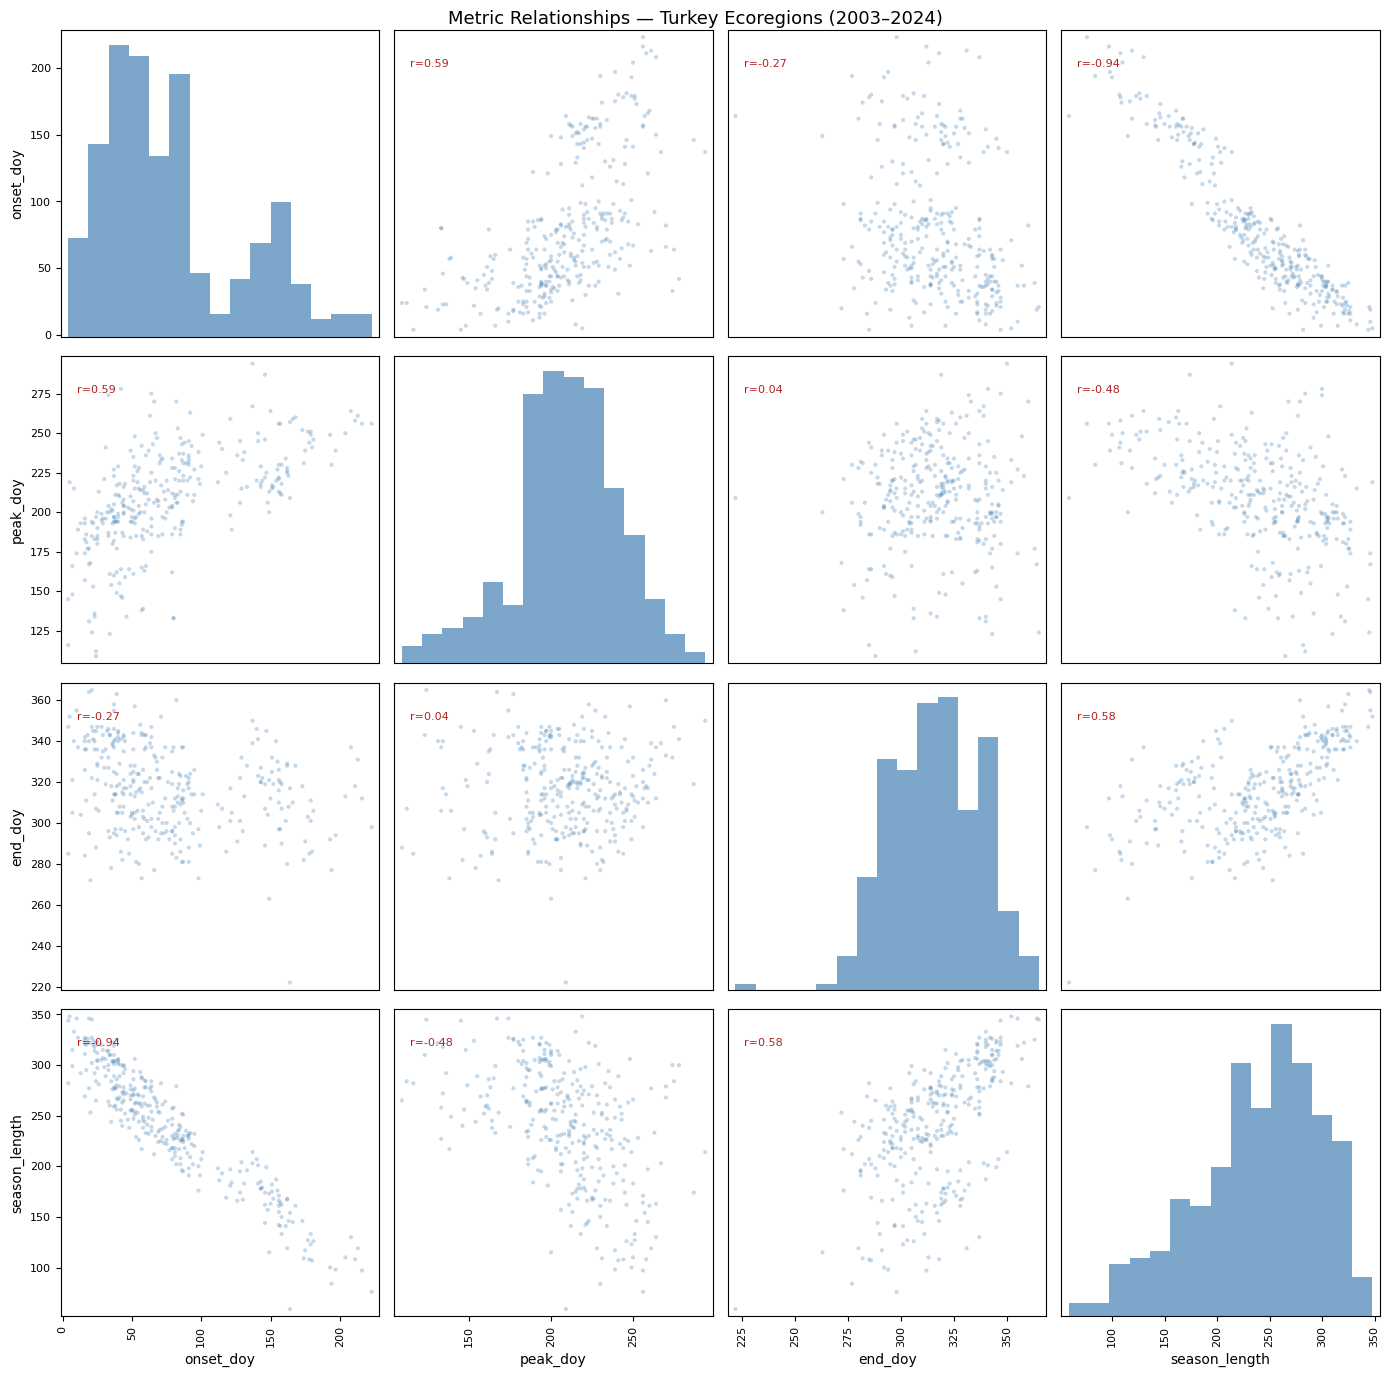

In [18]:
from pandas.plotting import scatter_matrix

cols = ['onset_doy', 'peak_doy', 'end_doy', 'season_length']

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
fig.suptitle('Metric Relationships — Turkey Ecoregions (2003–2024)', fontsize=13)

scatter_matrix(
    master_df[cols],
    ax           = axes,
    alpha        = 0.3,
    figsize      = (14, 14),
    diagonal     = 'hist',
    color        = 'steelblue',
    hist_kwds    = {'bins': 15, 'color': 'steelblue', 'alpha': 0.7}
)

# Add correlation values to each panel
for i, col1 in enumerate(cols):
    for j, col2 in enumerate(cols):
        if i != j:
            r, p = stats.pearsonr(
                master_df[col1].dropna(),
                master_df[col2].dropna()
            )
            axes[i, j].annotate(f'r={r:.2f}', xy=(0.05, 0.88),
                                 xycoords='axes fraction', fontsize=8,
                                 color='firebrick')

plt.tight_layout()
# plt.savefig(f'{output_dir}/scatter_matrix.png', dpi=150, bbox_inches='tight')
plt.show()